<a href="https://colab.research.google.com/github/maruthikelgire/Hybrid-ML-Model-for-Alzheimers/blob/main/Hybrid_Alzheimers_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
from itertools import cycle

# Ignore warnings for a cleaner output
warnings.filterwarnings('ignore')

In [ ]:
# In your Colab notebook

# --- Step 0: Loading and Preprocessing Data (Corrected) ---
print("--- Step 0: Loading and Preprocessing Data ---")

try:
    df = pd.read_csv('/content/alzheimers_disease_data_expanded.csv')

    # Clean data: Drop irrelevant ID columns
    df_cleaned = df.drop(['PatientID', 'DoctorInCharge'], axis=1)

    # Handle potential missing values
    for col in df_cleaned.select_dtypes(include=np.number).columns:
        if df_cleaned[col].isnull().any():
            df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].median())

    # --- THIS IS THE CRITICAL FIX ---
    # Create a mapping from the numbers in your CSV to their text meanings.
    # IMPORTANT: Please confirm this mapping is correct for your dataset.
    diagnosis_mapping = {
        0: 'Cognitively Normal',
        1: 'MCI',
        2: 'Alzheimer\'s Disease'
    }

    # Replace the numbers in the 'Diagnosis' column with the text labels.
    df_cleaned['Diagnosis'] = df_cleaned['Diagnosis'].map(diagnosis_mapping)

    # VERIFY that the labels are now correct text
    print("Cleaned Diagnosis Labels:", df_cleaned['Diagnosis'].unique())
    # The output should now be ['Cognitively Normal' 'Mci' 'Alzheimer's Disease']
    # --- END OF FIX ---

    # Separate features (X) and target (y)
    X = df_cleaned.drop('Diagnosis', axis=1)
    y = df_cleaned['Diagnosis']
    X_original_columns = X.columns.copy()

    # Now, the LabelEncoder will be trained on the correct text labels
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)
    class_names = le.classes_
    n_classes = len(class_names)

    # Scale numerical features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    print("\nData loading and preprocessing complete and corrected.")
    print(f"Dataset shape: {X_scaled.shape}")

except FileNotFoundError:
    print("Error: alzheimers_disease_data_expanded.csv not found.")

--- Step 0: Loading and Preprocessing Data ---
Cleaned Diagnosis Labels: ['Cognitively Normal' 'MCI']

Data loading and preprocessing complete and corrected.
Dataset shape: (4000, 32)


In [ ]:
  def calculate_fitness(features, X_train, y_train, X_test, y_test):
      """Helper function to calculate KNN accuracy for a feature subset."""
      selected_indices = np.where(features == 1)[0]
      # Return 0 if no features are selected to avoid errors
      if len(selected_indices) == 0:
          return 0

      knn = KNeighborsClassifier(n_neighbors=5)
      knn.fit(X_train[:, selected_indices], y_train)
      return knn.score(X_test[:, selected_indices], y_test)

In [ ]:
def boa_pso_feature_selection(X, y, num_agents=20, max_iter=40):
    """Performs feature selection using a hybrid BOA-PSO algorithm."""
    num_features = X.shape[1]
    agents = np.random.randint(2, size=(num_agents, num_features))
    velocities = np.zeros((num_agents, num_features))
    global_best_agent = np.zeros(num_features, dtype=int)
    global_best_fitness = -1
    personal_best_agents = np.copy(agents)
    personal_best_fitnesses = np.zeros(num_agents)

    # FIX: Added stratify=y to the internal train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    for iteration in range(max_iter):
        fitnesses = np.array([calculate_fitness(agent, X_train, y_train, X_test, y_test) for agent in agents])

        for i in range(num_agents):
            if fitnesses[i] > personal_best_fitnesses[i]:
                personal_best_fitnesses[i] = fitnesses[i]
                personal_best_agents[i] = np.copy(agents[i])

        current_best_idx = np.argmax(fitnesses)
        if fitnesses[current_best_idx] > global_best_fitness:
            global_best_fitness = fitnesses[current_best_idx]
            global_best_agent = np.copy(agents[current_best_idx])

        p_switch, a = 0.5, 0.1 + 0.2 * (1 - iteration / max_iter)
        w, c1, c2 = 0.9 - 0.5 * (iteration / max_iter), 2.0, 2.0

        for i in range(num_agents):
            r1, r2 = np.random.rand(), np.random.rand()
            if np.random.rand() < p_switch: # BOA phase
                fragrance = 0.01 * (fitnesses[i] ** a)
                step = (agents[i] - global_best_agent) * fragrance
                new_pos_continuous = agents[i] + step
            else: # PSO phase
                cognitive = c1 * r1 * (personal_best_agents[i] - agents[i])
                social = c2 * r2 * (global_best_agent - agents[i])
                velocities[i] = w * velocities[i] + cognitive + social
                new_pos_continuous = agents[i] + velocities[i]

            agents[i] = (1 / (1 + np.exp(-new_pos_continuous)) > np.random.rand(num_features)).astype(int)

    return global_best_agent

In [ ]:
def aco_feature_selection(X, y, n_ants=10, n_iterations=50, evaporation_rate=0.1):
    """Performs feature selection using the Ant Colony Optimization algorithm."""
    n_features = X.shape[1]
    pheromone = np.ones(n_features)
    global_best_accuracy = 0
    global_best_features = np.zeros(n_features, dtype=int)

    # FIX: Added stratify=y to the internal train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    for iteration in range(n_iterations):
        for ant in range(n_ants):
            selection_probs = pheromone / np.sum(pheromone)
            feature_subset = (selection_probs > np.random.uniform(0, np.mean(selection_probs))).astype(int)
            if np.sum(feature_subset) == 0:
                feature_subset[np.random.randint(0, n_features)] = 1

            accuracy = calculate_fitness(feature_subset, X_train, y_train, X_test, y_test)
            if accuracy > global_best_accuracy:
                global_best_accuracy = accuracy
                global_best_features = feature_subset

        pheromone *= (1 - evaporation_rate)
        pheromone += global_best_features * global_best_accuracy

    return global_best_features

In [ ]:
# @title
if not df.empty:
    # --- Stage 1: Run BOA-PSO Feature Selection ---
    print("--- Stage 1: Starting BOA-PSO Feature Selection ---")
    start_time = time.time()
    best_features_mask_boa = boa_pso_feature_selection(X_scaled, y_encoded)
    X_reduced_boa = X_scaled[:, best_features_mask_boa == 1]
    boa_selected_columns = X_original_columns[best_features_mask_boa == 1]

    print(f"BOA-PSO finished in {time.time() - start_time:.2f} seconds.")
    print(f"Features selected by BOA-PSO: {len(boa_selected_columns)}")
    print("Selected Features:", list(boa_selected_columns))

    # --- Stage 2: Run ACO Feature Selection on the Refined Set ---
    print("\n--- Stage 2: Starting ACO Feature Selection on Refined Set ---")
    start_time = time.time()
    best_features_mask_aco = aco_feature_selection(X_reduced_boa, y_encoded)
    X_final_reduced = X_reduced_boa[:, best_features_mask_aco == 1]
    final_selected_columns = boa_selected_columns[best_features_mask_aco == 1]

    print(f"ACO finished in {time.time() - start_time:.2f} seconds.")
    print(f"Final features selected after ACO refinement: {len(final_selected_columns)}")
    print("Final Selected Features:", list(final_selected_columns))

--- Stage 1: Starting BOA-PSO Feature Selection ---
BOA-PSO finished in 26.17 seconds.
Features selected by BOA-PSO: 19
Selected Features: ['Age', 'Gender', 'Ethnicity', 'BMI', 'AlcoholConsumption', 'DietQuality', 'SleepQuality', 'FamilyHistoryAlzheimers', 'Diabetes', 'DiastolicBP', 'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment', 'MemoryComplaints', 'BehavioralProblems', 'ADL', 'PersonalityChanges']

--- Stage 2: Starting ACO Feature Selection on Refined Set ---
ACO finished in 13.51 seconds.
Final features selected after ACO refinement: 19
Final Selected Features: ['Age', 'Gender', 'Ethnicity', 'BMI', 'AlcoholConsumption', 'DietQuality', 'SleepQuality', 'FamilyHistoryAlzheimers', 'Diabetes', 'DiastolicBP', 'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment', 'MemoryComplaints', 'BehavioralProblems', 'ADL', 'PersonalityChanges']


In [ ]:
# --- Create a Final Scaler for Deployment ---
# This happens AFTER you have your final_selected_columns list

# 1. Get the original (unscaled) data, but only the columns that were finally selected
X_final_features_unscaled = df_cleaned[final_selected_columns]

# 2. Create and fit a NEW scaler on ONLY these final columns
final_scaler = StandardScaler()
final_scaler.fit(X_final_features_unscaled)

print("✅ A new, final scaler has been created and trained for deployment.")

✅ A new, final scaler has been created and trained for deployment.


In [ ]:
# --- SANITY CHECK CELL ---
# This cell checks the training data right before it's used by the model.

# Check if the variable 'y_train_final' exists in the current scope
if 'y_train_final' in locals():
    # If it exists, analyze the classes within it
    unique_classes, counts = np.unique(y_train_final, return_counts=True)

    print("--- Sanity Check Results ---")
    print(f"Unique classes found in the FINAL TRAINING data: {unique_classes}")
    print(f"Counts of each class in the FINAL TRAINING data: {counts}")

    # Check if there is more than one class for the model to learn from
    if len(unique_classes) < 2:
        print("\n!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!")
        print("!!!      ERROR FOUND       !!!")
        print("!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!")
        print("\nDIAGNOSIS: The model is being trained on data with only ONE class.")
        print("This is the absolute cause of the IndexError in the ROC curve plot.")
        print("\nRECOMMENDATION: The feature selection process is too aggressive and is eliminating all features that distinguish the different classes. Try reducing the number of iterations in Cell 4 and Cell 5 (e.g., set max_iter=20 and n_iterations=25).")

    else:
        print("\nSuccess: The training data contains multiple classes. This is unexpected; please share the output.")
# This 'else' block executes if 'y_train_final' was never created
else:
    print("Could not perform sanity check because 'y_train_final' was not found.")

Could not perform sanity check because 'y_train_final' was not found.


In [ ]:
# @title
if not df.empty and 'X_final_reduced' in locals() and X_final_reduced.shape[1] > 0:
    # --- Stage 3: Train Classifiers and Create Hybrid Model ---
    print("\n--- Stage 3: Training Final Classifiers and Creating Hybrid Model ---")

    # FIX: Added stratify=y_encoded to ensure all classes are represented in train/test sets
    X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
        X_final_reduced, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
    )

    # 1. Train Random Forest Classifier
    print("Training Random Forest Classifier...")
    rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf_classifier.fit(X_train_final, y_train_final)
    y_proba_rf = rf_classifier.predict_proba(X_test_final)

    # 2. Train XGBoost Classifier
    print("Training XGBoost Classifier...")
    xgb_classifier = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
    xgb_classifier.fit(X_train_final, y_train_final)
    y_proba_xgb = xgb_classifier.predict_proba(X_test_final)

    # 3. Create Hybrid Model by averaging probabilities
    print("Creating Hybrid (RF + XGBoost) Model...")
    y_proba_hybrid = (y_proba_rf + y_proba_xgb) / 2.0

    # Get final predictions from probabilities
    y_pred_rf = np.argmax(y_proba_rf, axis=1)
    y_pred_xgb = np.argmax(y_proba_xgb, axis=1)
    y_pred_hybrid = np.argmax(y_proba_hybrid, axis=1)

    print("All models trained successfully.")
else:
    print("Skipping model training due to data loading or feature selection issues.")


--- Stage 3: Training Final Classifiers and Creating Hybrid Model ---
Training Random Forest Classifier...
Training XGBoost Classifier...
Creating Hybrid (RF + XGBoost) Model...
All models trained successfully.


In [ ]:
# @title
if not df.empty and 'X_final_reduced' in locals() and X_final_reduced.shape[1] > 0:
    # --- Final Model Evaluation ---
    print("\n--- Final Model Evaluation ---")

    # Calculate accuracy scores
    rf_accuracy = accuracy_score(y_test_final, y_pred_rf)
    xgb_accuracy = accuracy_score(y_test_final, y_pred_xgb)
    hybrid_accuracy = accuracy_score(y_test_final, y_pred_hybrid)

    print(f"Random Forest Alone Accuracy:   {rf_accuracy:.4f}")
    print(f"XGBoost Alone Accuracy:         {xgb_accuracy:.4f}")
    print(f"Hybrid (RF + XGBoost) Accuracy: {hybrid_accuracy:.4f}\n")

    # FIX: Ensure all class names are strings for the report
    target_names_str = [str(c) for c in class_names]

    print("--- Random Forest Classification Report ---")
    print(classification_report(y_test_final, y_pred_rf, target_names=target_names_str))

    print("--- XGBoost Classification Report ---")
    print(classification_report(y_test_final, y_pred_xgb, target_names=target_names_str))

    print("--- Hybrid (RF + XGBoost) Classification Report ---")
    print(classification_report(y_test_final, y_pred_hybrid, target_names=target_names_str))
else:
    print("Skipping final evaluation due to previous errors.")


--- Final Model Evaluation ---
Random Forest Alone Accuracy:   0.9917
XGBoost Alone Accuracy:         0.9908
Hybrid (RF + XGBoost) Accuracy: 0.9908

--- Random Forest Classification Report ---
                    precision    recall  f1-score   support

Cognitively Normal       0.99      0.99      0.99       763
               MCI       0.99      0.99      0.99       437

          accuracy                           0.99      1200
         macro avg       0.99      0.99      0.99      1200
      weighted avg       0.99      0.99      0.99      1200

--- XGBoost Classification Report ---
                    precision    recall  f1-score   support

Cognitively Normal       0.99      0.99      0.99       763
               MCI       0.99      0.99      0.99       437

          accuracy                           0.99      1200
         macro avg       0.99      0.99      0.99      1200
      weighted avg       0.99      0.99      0.99      1200

--- Hybrid (RF + XGBoost) Classification R


--- Generating Confusion Matrix Visualizations ---


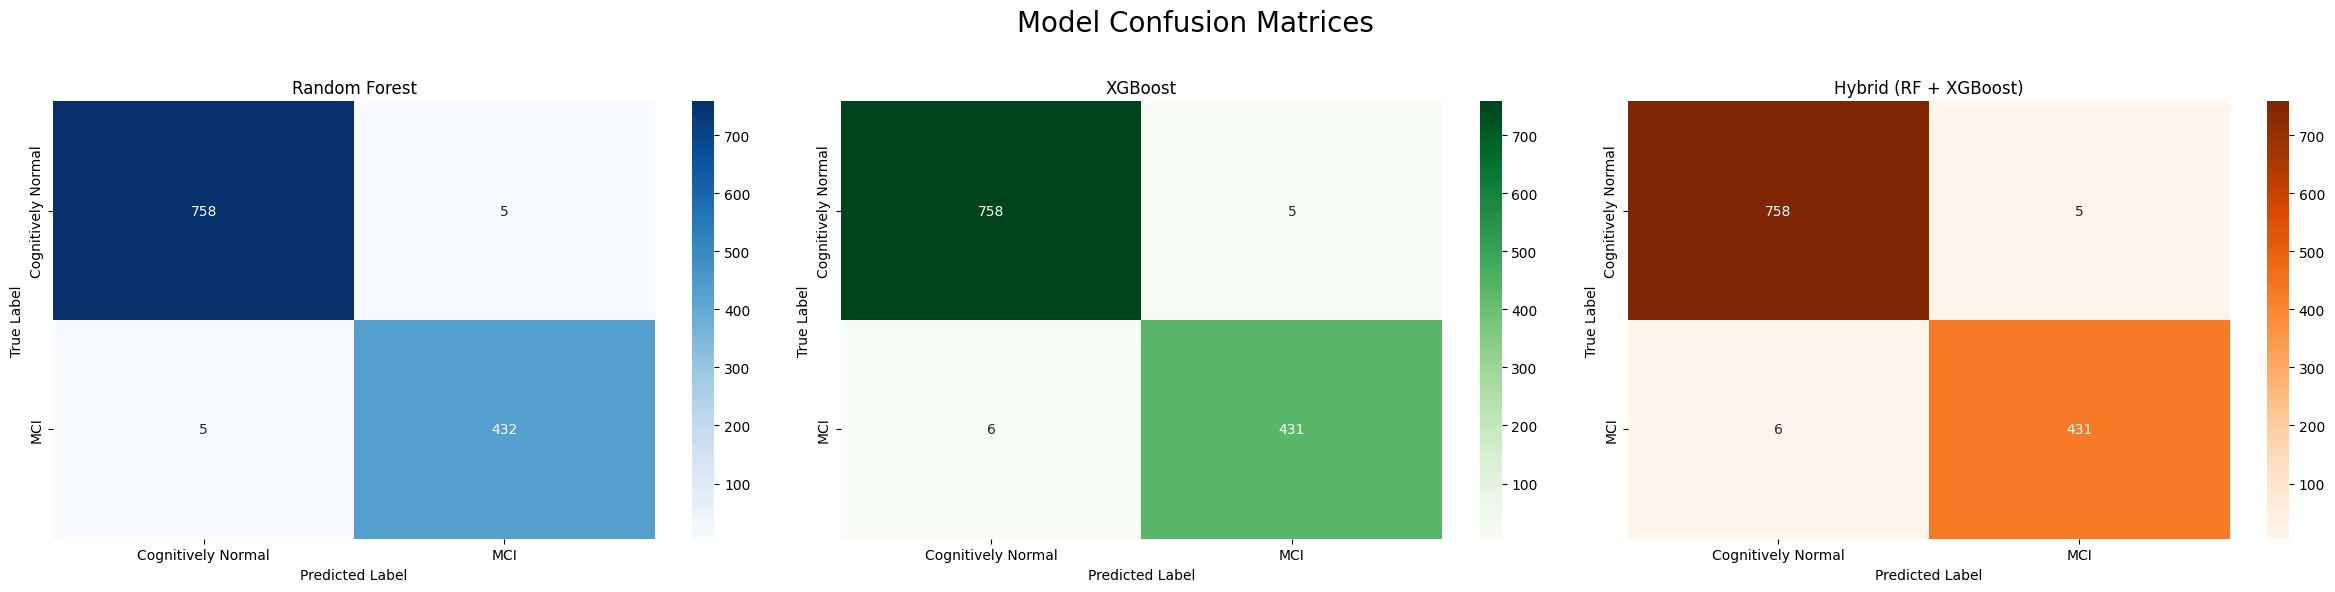

In [ ]:
# @title
if not df.empty and 'X_final_reduced' in locals() and X_final_reduced.shape[1] > 0:
    # --- Visualization 1: Confusion Matrices ---
    print("\n--- Generating Confusion Matrix Visualizations ---")
    fig, axes = plt.subplots(1, 3, figsize=(24, 6))
    fig.suptitle('Model Confusion Matrices', fontsize=20)

    sns.heatmap(confusion_matrix(y_test_final, y_pred_rf), annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=axes[0])
    axes[0].set_title('Random Forest')
    axes[0].set_xlabel('Predicted Label')
    axes[0].set_ylabel('True Label')

    sns.heatmap(confusion_matrix(y_test_final, y_pred_xgb), annot=True, fmt='d', cmap='Greens',
                xticklabels=class_names, yticklabels=class_names, ax=axes[1])
    axes[1].set_title('XGBoost')
    axes[1].set_xlabel('Predicted Label')
    axes[1].set_ylabel('True Label')

    sns.heatmap(confusion_matrix(y_test_final, y_pred_hybrid), annot=True, fmt='d', cmap='Oranges',
                xticklabels=class_names, yticklabels=class_names, ax=axes[2])
    axes[2].set_title('Hybrid (RF + XGBoost)')
    axes[2].set_xlabel('Predicted Label')
    axes[2].set_ylabel('True Label')

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
else:
    print("Skipping confusion matrix visualization.")


--- Generating Final ROC Curve Comparison ---


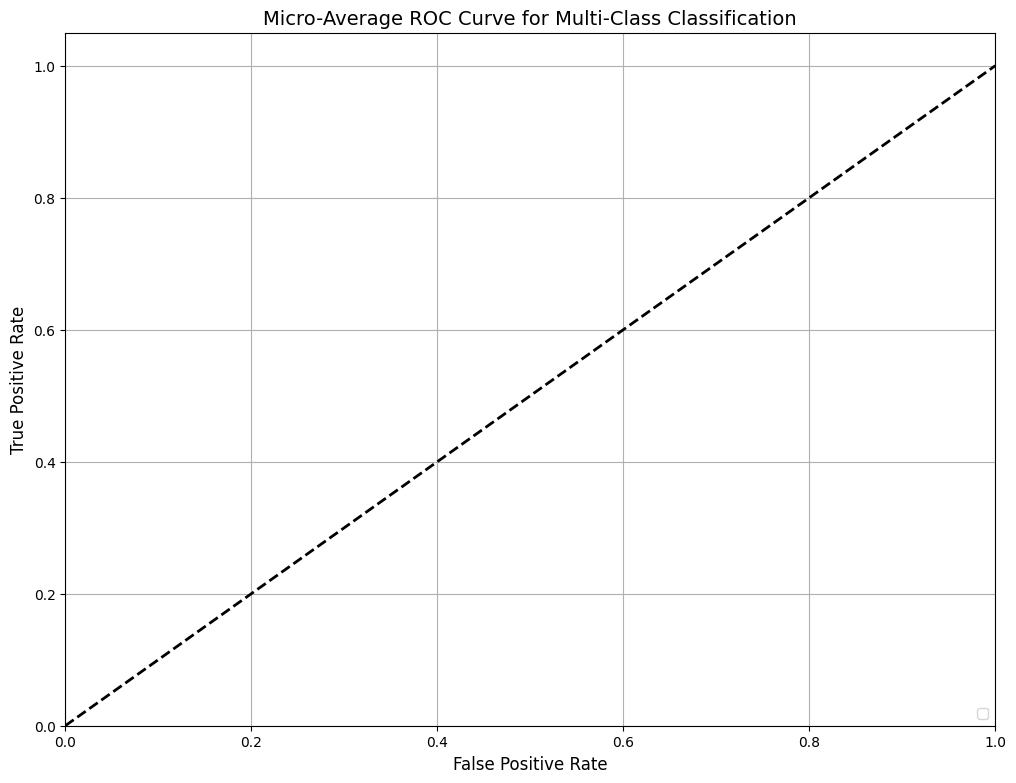

In [ ]:
# @title
if not df.empty and 'X_final_reduced' in locals() and X_final_reduced.shape[1] > 0:
    # --- Visualization 2: ROC Curves (Corrected) ---
    print("\n--- Generating Final ROC Curve Comparison ---")

    # Get the unique classes that are ACTUALLY present in the final test data
    final_classes_present = np.unique(y_test_final)

    # Binarize the test labels against ONLY the classes that are present.
    # This ensures y_test_binarized has the same number of columns as the model's output probabilities.
    y_test_binarized = label_binarize(y_test_final, classes=final_classes_present)

    model_probas = {'Random Forest': y_proba_rf, 'XGBoost': y_proba_xgb, 'Hybrid': y_proba_hybrid}
    colors = cycle(['blue', 'green', 'red'])

    plt.figure(figsize=(12, 9))

    for (model_name, probas), color in zip(model_probas.items(), colors):
        # The number of classes is determined by the model's output shape, not the original global variable
        n_classes_actual = probas.shape[1]

        # This check ensures the binarized labels and probabilities match
        if n_classes_actual != y_test_binarized.shape[1]:
            print(f"Warning: Mismatch in class numbers for {model_name}. Binarized y has {y_test_binarized.shape[1]} columns, but probabilities have {n_classes_actual}. Skipping ROC for this model.")
            continue

        fpr, tpr, roc_auc = dict(), dict(), dict()
        # Loop up to the ACTUAL number of classes predicted by the model
        for i in range(n_classes_actual):
            fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], probas[:, i])
            roc_auc[i] = auc(fpr[i], tpr[i])

        # Compute micro-average ROC curve and ROC area
        fpr["micro"], tpr["micro"], _ = roc_curve(y_test_binarized.ravel(), probas.ravel())
        roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

        plt.plot(fpr["micro"], tpr["micro"], color=color, lw=2,
                 label=f'{model_name} (AUC = {roc_auc["micro"]:.3f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('Micro-Average ROC Curve for Multi-Class Classification', fontsize=14)
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()
else:
    print("Skipping ROC curve visualization due to earlier errors.")

In [ ]:
#Hyper parameter tuning

In [ ]:
# @title
from sklearn.model_selection import GridSearchCV

# This cell assumes you have your final feature-selected data ready:
# X_train_final, y_train_final

# --- 1. Tuning the Random Forest Model ---
print("--- Starting Hyperparameter Tuning for Random Forest ---")
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, 30],
    'min_samples_leaf': [1, 2],
    'criterion': ['gini', 'entropy']
}
grid_search_rf = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                              param_grid=param_grid_rf, cv=5, n_jobs=-1, verbose=1)
grid_search_rf.fit(X_train_final, y_train_final)
best_rf_model = grid_search_rf.best_estimator_
print(f"Best Parameters for Random Forest: {grid_search_rf.best_params_}")


# --- 2. Tuning the XGBoost Model ---
print("\n--- Starting Hyperparameter Tuning for XGBoost ---")
param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 15],
    'learning_rate': [0.05, 0.1, 0.2],
    'gamma': [0, 0.1]
}
grid_search_xgb = GridSearchCV(estimator=XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42),
                               param_grid=param_grid_xgb, cv=5, n_jobs=-1, verbose=1)
grid_search_xgb.fit(X_train_final, y_train_final)
best_xgb_model = grid_search_xgb.best_estimator_
print(f"Best Parameters for XGBoost: {grid_search_xgb.best_params_}")

print("\n✅ Hyperparameter tuning complete for both models.")

--- Starting Hyperparameter Tuning for Random Forest ---
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters for Random Forest: {'criterion': 'gini', 'max_depth': 20, 'min_samples_leaf': 1, 'n_estimators': 200}

--- Starting Hyperparameter Tuning for XGBoost ---
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Parameters for XGBoost: {'gamma': 0, 'learning_rate': 0.2, 'max_depth': 10, 'n_estimators': 100}

✅ Hyperparameter tuning complete for both models.


In [ ]:
# @title
from sklearn.model_selection import KFold
from sklearn.base import clone
from sklearn.metrics import accuracy_score

# 1. Initialize K-Fold and score lists
kfold = KFold(n_splits=10, shuffle=True, random_state=42)
rf_scores, xgb_scores, hybrid_scores = [], [], []

print("--- Performing 10-Fold Cross-Validation for all models ---")
# Use the full feature-selected dataset
X = X_final_reduced
y = y_encoded

# 2. Loop through each fold
for fold, (train_index, test_index) in enumerate(kfold.split(X, y)):
    print(f"Processing Fold {fold+1}/10...")
    # Split data for this fold
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # Clone the best models to ensure they are retrained fresh for each fold
    rf_fold_model = clone(best_rf_model)
    xgb_fold_model = clone(best_xgb_model)

    # Fit models on the training fold
    rf_fold_model.fit(X_train, y_train)
    xgb_fold_model.fit(X_train, y_train)

    # --- Evaluate Individual Models ---
    rf_pred = rf_fold_model.predict(X_test)
    xgb_pred = xgb_fold_model.predict(X_test)
    rf_scores.append(accuracy_score(y_test, rf_pred))
    xgb_scores.append(accuracy_score(y_test, xgb_pred))

    # --- Evaluate Hybrid Model ---
    proba_rf = rf_fold_model.predict_proba(X_test)
    proba_xgb = xgb_fold_model.predict_proba(X_test)
    hybrid_proba = (proba_rf + proba_xgb) / 2.0
    hybrid_pred = np.argmax(hybrid_proba, axis=1)
    hybrid_scores.append(accuracy_score(y_test, hybrid_pred))

# 3. Calculate and print final average scores
print("\n--- Cross-Validation Results ---")
print(f"Tuned Random Forest:  Accuracy = {np.mean(rf_scores):.4f} (+/- {np.std(rf_scores):.4f})")
print(f"Tuned XGBoost:        Accuracy = {np.mean(xgb_scores):.4f} (+/- {np.std(xgb_scores):.4f})")
print(f"Final Hybrid Model:   Accuracy = {np.mean(hybrid_scores):.4f} (+/- {np.std(hybrid_scores):.4f})")

--- Performing 10-Fold Cross-Validation for all models ---
Processing Fold 1/10...
Processing Fold 2/10...
Processing Fold 3/10...
Processing Fold 4/10...
Processing Fold 5/10...
Processing Fold 6/10...
Processing Fold 7/10...
Processing Fold 8/10...
Processing Fold 9/10...
Processing Fold 10/10...

--- Cross-Validation Results ---
Tuned Random Forest:  Accuracy = 0.9927 (+/- 0.0039)
Tuned XGBoost:        Accuracy = 0.9925 (+/- 0.0030)
Final Hybrid Model:   Accuracy = 0.9930 (+/- 0.0033)


In [ ]:
# @title
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score

# 1. Create a dictionary of baseline models to compare against
baseline_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Support Vector Machine': SVC()
}

print("\n--- Comparing with Baseline Models ---")
# 2. Evaluate each baseline model using cross-validation
for name, model in baseline_models.items():
    kfold = KFold(n_splits=10, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X_final_reduced, y_encoded, cv=kfold, scoring='accuracy')
    print(f"{name}: Accuracy = {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# 3. Print the results from your tuned models again for a complete leaderboard
print("--- Final Model Leaderboard ---")
print(f"Tuned Random Forest:  Accuracy = {np.mean(rf_scores):.4f} (+/- {np.std(rf_scores):.4f})")
print(f"Tuned XGBoost:        Accuracy = {np.mean(xgb_scores):.4f} (+/- {np.std(xgb_scores):.4f})")
print(f"Final Hybrid Model:   Accuracy = {np.mean(hybrid_scores):.4f} (+/- {np.std(hybrid_scores):.4f})")


--- Comparing with Baseline Models ---
Logistic Regression: Accuracy = 0.8450 (+/- 0.0171)
Support Vector Machine: Accuracy = 0.9297 (+/- 0.0098)
--- Final Model Leaderboard ---
Tuned Random Forest:  Accuracy = 0.9927 (+/- 0.0039)
Tuned XGBoost:        Accuracy = 0.9925 (+/- 0.0030)
Final Hybrid Model:   Accuracy = 0.9930 (+/- 0.0033)


In [ ]:
##Implement Model Explainability (XAI)

In [ ]:
!pip install shap


--- Generating SHAP Explanation for Random Forest ---


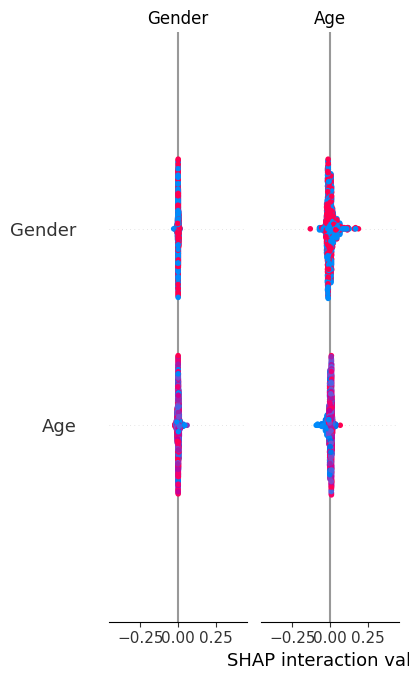


--- Generating SHAP Explanation for XGBoost ---


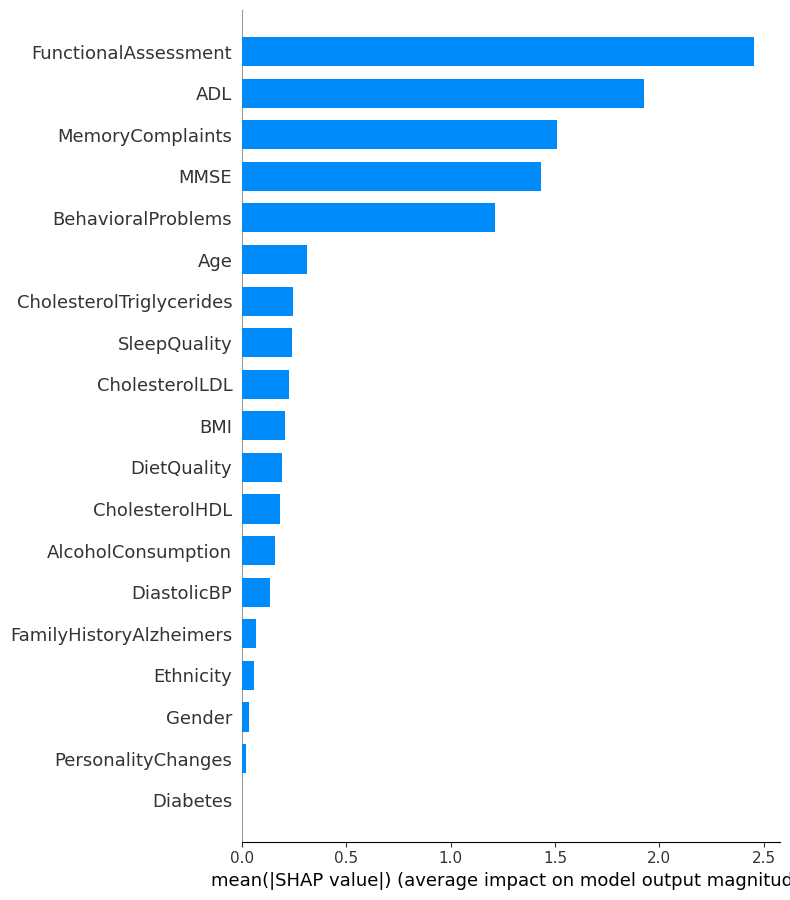

In [ ]:
# @title
import shap

# --- 1. Explain the Tuned Random Forest Model ---
print("\n--- Generating SHAP Explanation for Random Forest ---")
# Create a SHAP explainer for the RF model
rf_explainer = shap.TreeExplainer(best_rf_model)
# Calculate SHAP values on the test set
rf_shap_values = rf_explainer.shap_values(X_test_final)
# Create a summary plot
shap.summary_plot(rf_shap_values, X_test_final, plot_type="bar",
                  feature_names=final_selected_columns,
                  class_names=le.classes_,
                  title="Feature Importance for Random Forest")



# --- 2. Explain the Tuned XGBoost Model ---
print("\n--- Generating SHAP Explanation for XGBoost ---")
# Create a SHAP explainer for the XGB model
xgb_explainer = shap.TreeExplainer(best_xgb_model)
# Calculate SHAP values
xgb_shap_values = xgb_explainer.shap_values(X_test_final)
# Create a summary plot
shap.summary_plot(xgb_shap_values, X_test_final, plot_type="bar",
                  feature_names=final_selected_columns,
                  title="Feature Importance for XGBoost")

In [ ]:
# In your Colab notebook (this should be the last cell)
from sklearn.preprocessing import StandardScaler
import joblib

# --- 1. Create a Final Scaler for Deployment ---
# This creates a new scaler that is trained on ONLY the final selected features
X_final_features_unscaled = df_cleaned[final_selected_columns]
final_scaler = StandardScaler()
final_scaler.fit(X_final_features_unscaled)
print("✅ A new, final scaler has been created for deployment.")

# --- 2. Package All Assets for Deployment ---
# This dictionary contains all the final, correctly trained assets
project_assets = {
    'best_rf_model': best_rf_model,
    'best_xgb_model': best_xgb_model,
    'scaler': final_scaler,  # Saving the NEW, corrected scaler
    'label_encoder': le,
    'final_selected_columns': final_selected_columns
}

# --- 3. Save the Complete Package to a File ---
filename = 'alzheimers_deployment_assets1.joblib'
joblib.dump(project_assets, filename)
print(f"\n✅ Project successfully packaged. You can now download '{filename}' and use it for your web app.")

✅ A new, final scaler has been created for deployment.

✅ Project successfully packaged. You can now download 'alzheimers_deployment_assets1.joblib' and use it for your web app.


In [ ]:
##optional


In [ ]:
from sklearn.preprocessing import StandardScaler
import joblib

# --- 1. Create a Final Scaler for Deployment ---
# This step is crucial to prevent the feature name mismatch error.
# We create a new scaler that is only aware of the final selected features.

# Get the original (unscaled) data, but only for the columns that were finally selected
X_final_features_unscaled = df_cleaned[final_selected_columns]

# Create and fit the new scaler on ONLY these final columns
final_scaler = StandardScaler()
final_scaler.fit(X_final_features_unscaled)

print("✅ A new, final scaler has been created and trained specifically for deployment.")


# --- 2. Package All Assets for Deployment ---
# Create a dictionary containing all the final assets your application will need.
project_assets = {
    'best_rf_model': best_rf_model,
    'best_xgb_model': best_xgb_model,
    'scaler': final_scaler,  # <-- IMPORTANT: We are saving the NEW, corrected scaler
    'label_encoder': le,
    'final_selected_columns': final_selected_columns
}

# --- 3. Save the Complete Package to a File ---
# Define a filename for your deployment assets.
filename = 'alzheimers_deployment_assets.joblib'

# Save the entire dictionary to this single file using joblib.
joblib.dump(project_assets, filename)

print(f"\n✅ Project successfully packaged. You can now download '{filename}' and use it for your web app.")

✅ A new, final scaler has been created and trained specifically for deployment.

✅ Project successfully packaged. You can now download 'alzheimers_deployment_assets.joblib' and use it for your web app.


In [ ]:
# In your Colab notebook, in your XAI cell

# This creates the detailed beeswarm plot
shap.summary_plot(shap_values, X_test_final, feature_names=final_selected_columns)

NameError: name 'shap' is not defined